# Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency
0,1,56,Female,58088,46,23
1,2,69,Male,118196,29,42
2,3,46,Male,70479,62,44
3,4,32,Female,34963,93,14
4,5,60,Male,70123,62,14


In [4]:
print(df.isnull().sum())

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
dtype: int64


In [9]:
df = df.dropna()
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
X = df[['Annual_Income', 'Spending_Score', 'Age']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

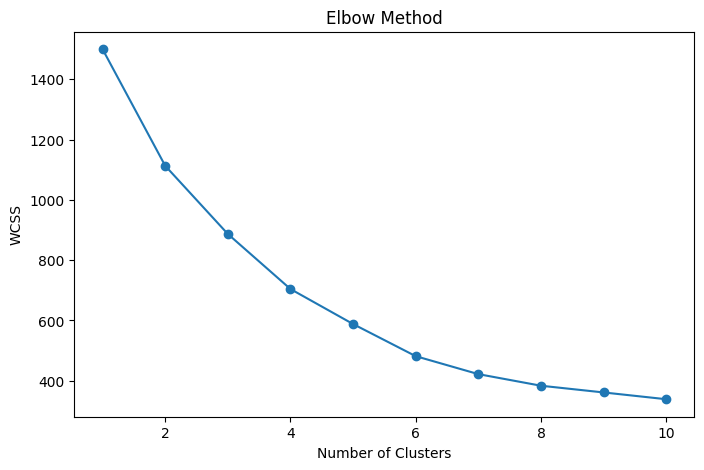

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans
df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Cluster
0,1,56,NaN,58088,46,23,4
1,2,69,NaN,118196,29,42,1
2,3,46,NaN,70479,62,44,0
3,4,32,NaN,34963,93,14,3
4,5,60,NaN,70123,62,14,4


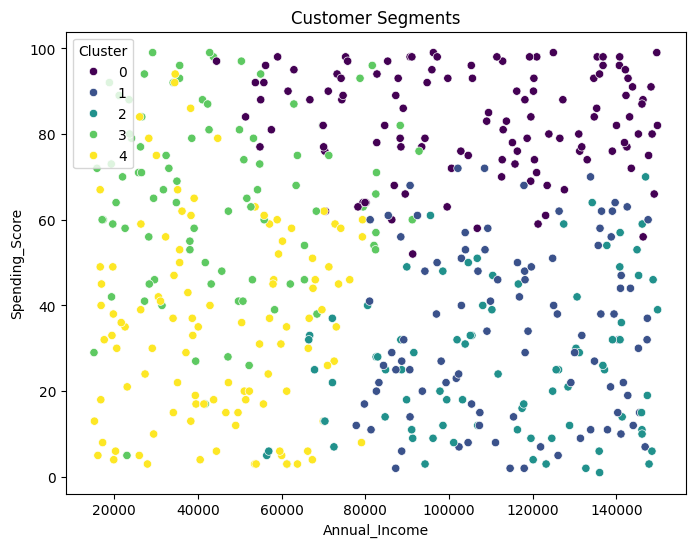

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title('Customer Segments')
plt.show()

In [15]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         Customer_ID        Age  Gender  Annual_Income  Spending_Score  \
Cluster                                                                  
0         245.058333  43.383333     NaN  107158.091667       83.025000   
1         262.052083  58.135417     NaN  115230.875000       34.375000   
2         235.186047  30.058140     NaN  111611.604651       26.244186   
3         245.426966  30.651685     NaN   45118.573034       65.775281   
4         262.541284  55.137615     NaN   45129.908257       35.715596   

         Purchase_Frequency  
Cluster                      
0                 26.133333  
1                 23.385417  
2                 24.883721  
3                 23.112360  
4                 25.119266  


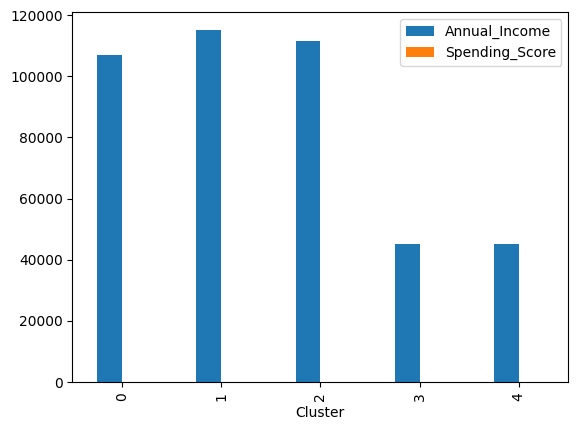

In [16]:
cluster_summary[['Annual_Income','Spending_Score']].plot(kind='bar')
plt.show()